In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score,f1_score,confusion_matrix,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')


Loan Eligibility Classification Using K-Nearest Neighbors (KNN) Project

In [4]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\KNN\train_u6lujuX_CVtuZ9i.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


EDA loan status ratio


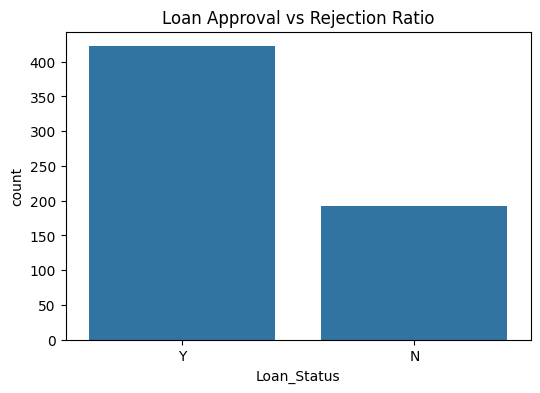

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval vs Rejection Ratio')
plt.savefig('loan_status_ratio.png')


EDA - Distribution of ApplicantIncome

Text(0.5, 1.0, 'Applicant Income Distribution')

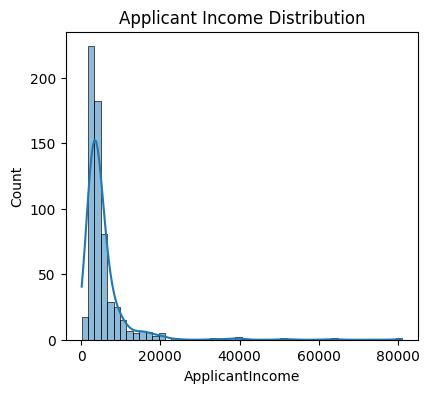

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Applicant Income Distribution')



EDA - Distribution of LoanAmount

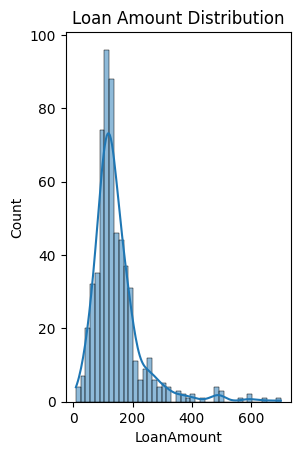

In [10]:
plt.subplot(1, 2, 2)
sns.histplot(df['LoanAmount'].dropna(), kde=True)
plt.title('Loan Amount Distribution')
plt.savefig('distributions.png')


Feature Influence - Credit_History vs Loan_Status

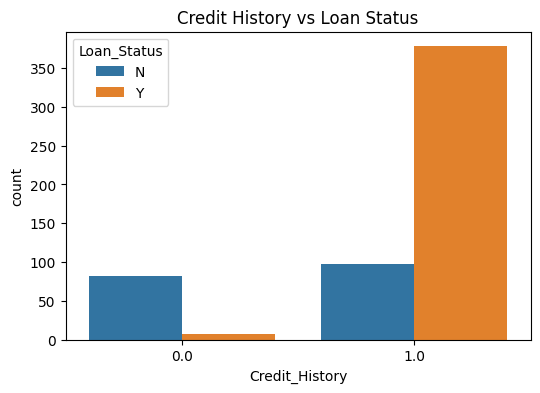

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.savefig('credit_history_influence.png')

In [12]:
# Missing Value Treatment
df_cleaned = df.copy()


Categorical columns imputation with Mode

In [13]:

cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

In [14]:

# Numerical column imputation with Median
df_cleaned['LoanAmount'] = df_cleaned['LoanAmount'].fillna(df_cleaned['LoanAmount'].median())

In [15]:
# Encoding
# Ordinal: Education (Graduate > Not Graduate), Dependents (0 < 1 < 2 < 3+)
df_cleaned['Education'] = df_cleaned['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_cleaned['Dependents'] = df_cleaned['Dependents'].replace('3+', 3).astype(int)

In [16]:
# Binary/Nominal: Gender, Married, Self_Employed, Property_Area, Loan_Status
df_cleaned['Gender'] = df_cleaned['Gender'].map({'Male': 1, 'Female': 0})
df_cleaned['Married'] = df_cleaned['Married'].map({'Yes': 1, 'No': 0})
df_cleaned['Self_Employed'] = df_cleaned['Self_Employed'].map({'Yes': 1, 'No': 0})

In [17]:
# Property Area - One Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['Property_Area'], drop_first=False)

In [18]:
# Target Variable
df_cleaned['Loan_Status'] = df_cleaned['Loan_Status'].map({'Y': 1, 'N': 0})

In [19]:
# Prepare data for Scaling Experiments
X = df_cleaned.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df_cleaned['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
results = []
scalers = {'No Scaling': None, 'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler()}

for name, scaler in scalers.items():
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Scaler': name, 'Accuracy': acc})
print(pd.DataFrame(results))

           Scaler  Accuracy
0      No Scaling  0.650407
1  StandardScaler  0.837398
2    MinMaxScaler  0.829268


In [21]:
# Using StandardScaler as it performed best
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.metrics import  recall_score

In [23]:
k_range = range(1, 41)
accuracy_scores = []
recall_rejection_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    # Recall for Loan Rejection (class 0)
    # pos_label for recall_score is usually 1, so we calculate recall for 0
    rec_rej = recall_score(y_test, y_pred, pos_label=0)
    recall_rejection_scores.append(rec_rej)

Text(0, 0.5, 'Accuracy')

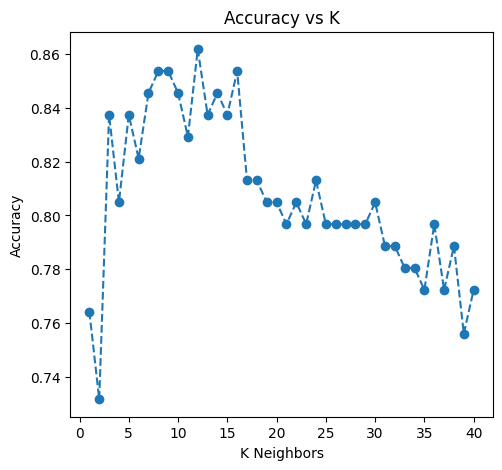

In [24]:
# Plotting Accuracy and Recall vs K
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
plt.title('Accuracy vs K')
plt.xlabel('K Neighbors')
plt.ylabel('Accuracy')


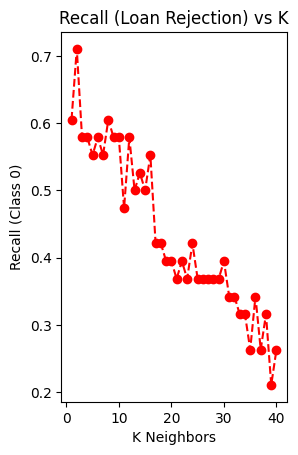

In [25]:
plt.subplot(1, 2, 2)
plt.plot(k_range, recall_rejection_scores, marker='o', color='red', linestyle='--')
plt.title('Recall (Loan Rejection) vs K')
plt.xlabel('K Neighbors')
plt.ylabel('Recall (Class 0)')
plt.savefig('k_tuning.png')

In [26]:
# Choosing optimal K
# Looking for high recall for rejection while maintaining decent accuracy
# Let's find K with max recall_rejection, if tied, pick highest accuracy.
best_k_idx = np.argmax(recall_rejection_scores)
best_k = k_range[best_k_idx]
print(f"Optimal K based on Risk Minimization: {best_k}")

Optimal K based on Risk Minimization: 2


In [27]:
# Final Model Evaluation
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)
y_prob_final = knn_final.predict_proba(X_test_scaled)[:, 1]

In [28]:
# Final Model Evaluation
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)
y_prob_final = knn_final.predict_proba(X_test_scaled)[:, 1]

In [29]:

cm = confusion_matrix(y_test, y_pred_final)
report = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall (Approval)': recall_score(y_test, y_pred_final),
    'Recall (Rejection)': recall_score(y_test, y_pred_final, pos_label=0),
    'F1-Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_prob_final)
}

print("Confusion Matrix:\n", cm)
print("Final Model Report:", report)

Confusion Matrix:
 [[27 11]
 [22 63]]
Final Model Report: {'Accuracy': 0.7317073170731707, 'Precision': 0.8513513513513513, 'Recall (Approval)': 0.7411764705882353, 'Recall (Rejection)': 0.7105263157894737, 'F1-Score': 0.7924528301886793, 'ROC-AUC': 0.7704334365325077}


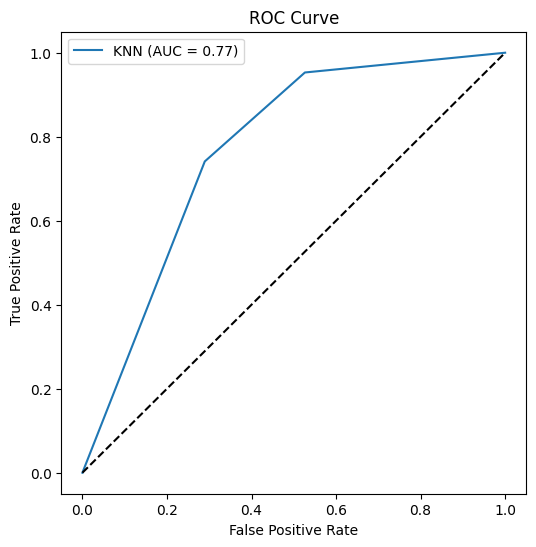

In [30]:
# Plotting ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {report["ROC-AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png')

In [32]:
column_list = X.columns.tolist()

In [34]:
import pickle
import os

path = r'C:\Users\HP\OneDrive\Desktop\python\Machine learning\Loan-knn-approval-predictor\model'

os.makedirs(path, exist_ok=True)

with open(os.path.join(path,"model.pkl"),"wb") as f:
    pickle.dump(knn_final,f)

with open(os.path.join(path,"scaler.pkl"),"wb") as f:
    pickle.dump(scaler,f)

with open(os.path.join(path,"columns.pkl"),"wb") as f:
    pickle.dump(column_list,f)

print("Model files saved successfully")

Model files saved successfully
